In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import  DistilBertForSequenceClassification, DistilBertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
import os
from sklearn.model_selection import train_test_split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

checkpoint_dir = "/content/drive/MyDrive/Bert_weights/bert_checkpoints"
os.makedirs(checkpoint_dir, exist_ok = True)

Mounted at /content/drive


In [ ]:


file_path = "/content/drive/MyDrive/Ds/financial_news_base.jsonl"

df = pd.read_json(file_path, lines=True)


In [ ]:
df.columns

target_per_class = 25000 // 3
df_balanced = df.groupby("sentiment_label").apply(lambda x: x.sample(n=target_per_class, random_state=100)).reset_index(drop=True)

df_balanced.groupby("sentiment_label").agg({"sentiment_label" : "count"})



/tmp/ipykernel_172/2517719507.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby("sentiment_label").apply(lambda x: x.sample(n=target_per_class, random_state=100)).reset_index(drop=True)


,sentiment_label
sentiment_label,
negative,8333
neutral,8333
positive,8333


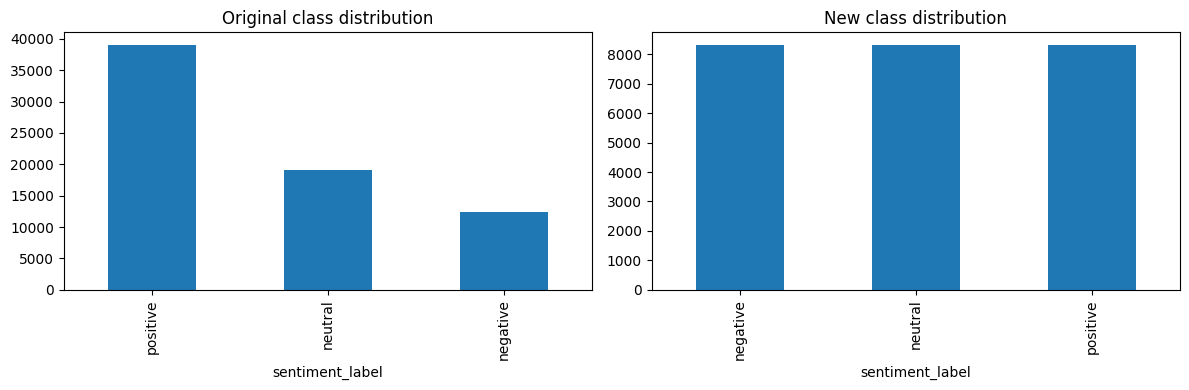

In [ ]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[0], title='Original class distribution')
df_balanced['sentiment_label'].value_counts().plot(kind='bar', ax=axes[1], title='New class distribution')

plt.tight_layout()
plt.show()

In [ ]:
df_bert = df_balanced[["description","sentiment_label"]]



In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:

X = df_bert["description"]
y = df_bert["sentiment_label"].replace({"negative" : 0 , "neutral":1, "positive" : 2})

X_train, X_temp, y_train, y_temp = train_test_split(X,y, test_size = 0.3, random_state = 100)

X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp, test_size = 0.5, random_state = 100)

print(X_train.shape, X_val.shape, X_test.shape)
y_train.head()


(17499,) (3750,) (3750,)


/tmp/ipykernel_172/619825280.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df_bert["sentiment_label"].replace({"negative" : 0 , "neutral":1, "positive" : 2})


,sentiment_label
15970,1
14574,1
21395,2
2037,0
19629,2


In [ ]:
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

batch_texts = X_train.tolist()
train_tokenized = tokenizer(batch_texts,
                      padding="max_length",
                      truncation=True,
                      return_tensors="pt")

val_tokenized = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)

test_tokenized = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding="max_length",
    return_tensors="pt"
)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
y_train_tensor = torch.tensor(y_train.values)
y_val_tensor = torch.tensor(y_val.values)
y_test_tensor = torch.tensor(y_test.values)

In [ ]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self,tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
      item = {key: val[idx] for key, val in self.tokens.items()}
      item["labels"] = self.labels[idx]
      return item

  def __len__(self):
      return len(self.labels)

In [ ]:
#train_dataset = Dataset(train_tokenized, y_train_tensor)
#val_dataset = Dataset(val_tokenized, y_val_tensor)
#test_dataset = Dataset(test_tokenized, y_test_tensor)


#train_loader = DataLoader(train_dataset, batch_size = 16)
#val_loader = DataLoader(val_dataset, batch_size = 16)
#test_loader = DataLoader(test_dataset, batch_size = 16)

In [ ]:
import time
from tqdm import tqdm


def train_epoch(model ,dataloader, optimizer, scheduler, device):
  model.train()
  total_loss = 0

  for batch in tqdm(dataloader, desc = "Training"):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()

        # Forward pass: compute model predictions and loss
        # BertForSequenceClassification automatically computes loss when labels are provided
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss

        # Backward pass: compute gradients
    loss.backward()

        # Update weights based on gradients
    optimizer.step()

    scheduler.step()

    total_loss += loss.item()

  return total_loss / len(dataloader)

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
    return total_loss / len(dataloader)

# NEXT CELL: TRAIN FOR COLAB

In [ ]:

batch_sizes = 64
learning_rates = 2e-5
warmup_ratios = 0.1

best_val_loss = float('inf')
best_hparams = None


def save_checkpoint(model, optimizer, scheduler, epoch,
                    val_losses, best_val_loss, best_hparams,
                    completed_configs,path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'best_hparams': best_hparams,
        'completed_configs': completed_configs
    }, path)
    print(f"Checkpoint saved at {path}")

def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    return (ckpt['epoch'],
            ckpt.get('val_losses', []),
            ckpt.get('best_val_loss', float('inf')),
            ckpt.get('best_hparams', None),
            ckpt.get('completed_configs', set()))

def config_key(bs, lr, wr):
    return f"bs{bs}_lr{lr}_wr{wr}"

best_val_loss     = float('inf')
best_hparams      = None
completed_configs = set()

global_ckpt_path = os.path.join(checkpoint_dir, "global_progress.pt")
if os.path.exists(global_ckpt_path):
    global_ckpt = torch.load(global_ckpt_path, map_location=device)
    best_val_loss     = global_ckpt.get('best_val_loss', float('inf'))
    best_hparams      = global_ckpt.get('best_hparams', None)
    completed_configs = global_ckpt.get('completed_configs', set())
    print(f"🔄 Resumed global progress — {len(completed_configs)} configs done")

for batch_size in batch_sizes:
    for lr in learning_rates:
        for warmup_ratio in warmup_ratios:

            key = config_key(batch_size, lr, warmup_ratio)
            if key in completed_configs:
                print(f"⏭️  Skipping already-done config: {key}")
                continue

            print(f"\nTesting: batch_size={batch_size}, lr={lr}, warmup_ratio={warmup_ratio}")

            train_loader = DataLoader(Dataset(train_tokenized, y_train_tensor), batch_size=batch_size)
            val_loader = DataLoader(Dataset(val_tokenized, y_val_tensor), batch_size=batch_size)

            config_finetune = DistilBertConfig.from_pretrained('distilbert-base-uncased', num_labels=3, output_attentions=True)
            model_finetune = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", config = config_finetune)

            model_finetune.to(device)

            optimizer = AdamW(model_finetune.parameters(), lr=lr, weight_decay = 0.01)
            epochs = 3
            total_steps = len(train_loader) * epochs
            scheduler = get_linear_schedule_with_warmup(
                optimizer,
                num_warmup_steps=int(warmup_ratio * total_steps),
                num_training_steps=total_steps)
            start_epoch = 0
            val_losses = []
            mid_ckpt_path = os.path.join(checkpoint_dir, f"bert_{key}_latest.pt")

            if os.path.exists(mid_ckpt_path):
                start_epoch, val_losses, best_val_loss, best_hparams, completed_configs = \
                    load_checkpoint(mid_ckpt_path, model_finetune, optimizer, scheduler)
                start_epoch += 1   # resume from the NEXT epoch
                print(f"🔄 Resuming {key} from epoch {start_epoch + 1}/{epochs}")

            for epoch in range(start_epoch, epochs):
                print(f"\n📍 Epoch {epoch + 1}/{epochs}")
                train_loss = train_epoch(model_finetune, train_loader, optimizer, scheduler, device)
                val_loss = eval_epoch(model_finetune, val_loader, device)
                val_losses.append(val_loss)
                print(f"Epoch {epoch+1} — Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")


                save_checkpoint(model_finetune, optimizer, scheduler, epoch, val_losses, best_val_loss, best_hparams,
                                completed_configs, mid_ckpt_path)

            avg_val_loss = sum(val_losses) / len(val_losses)
            print(f"Avg validation loss: {avg_val_loss:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                best_hparams = {'batch_size': batch_size, 'lr': lr, 'warmup_ratio': warmup_ratio}

            completed_configs.add(key)

            # save global progress after each completed config
            torch.save({
                'best_val_loss':     best_val_loss,
                'best_hparams':      best_hparams,
                'completed_configs': completed_configs,
            }, global_ckpt_path)

print("\n✅ Best hyperparameters:", best_hparams)
print("Validation loss:", best_val_loss)




Testing: batch_size=16, lr=3e-05, warmup_ratio=0.1


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔄 Resuming bs16_lr3e-05_wr0.1 from epoch 2/3

📍 Epoch 2/3


Training:   0%|          | 0/3087 [00:00<?, ?it/s]

# NEXT CELL: TRAIN FOR GPU

In [30]:
batch_size = 64
lr = 2e-5
warmup_ratio = 0.1

best_val_loss = float('inf')
train_losses = []
val_losses = []
train_loader = DataLoader(Dataset(train_tokenized, y_train_tensor), batch_size=batch_size)
val_loader = DataLoader(Dataset(val_tokenized, y_val_tensor), batch_size=batch_size)

config_finetune = DistilBertConfig.from_pretrained('distilbert-base-uncased', num_labels=3, output_attentions=True)
model_finetune = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", config=config_finetune)

model_finetune.to(device)

optimizer = AdamW(model_finetune.parameters(), lr=lr, weight_decay=0.01)
epochs = 5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(warmup_ratio * total_steps),
    num_training_steps=total_steps)


patience = 2   # consecutive epochs with no improvement (greater than min_delta) in validation loss.
min_delta = 0.01
patience_counter = 0
best_val_loss = float('inf')
best_epoch = -1
best_ckpt_path = os.path.join(checkpoint_dir, "bert_best_model.pt")

for epoch in range(epochs):
    print(f"\n Epoch {epoch + 1}/{epochs}")
    train_loss = train_epoch(model_finetune, train_loader, optimizer, scheduler, device)
    val_loss = eval_epoch(model_finetune, val_loader, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1} — Training loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")

    # Check if improved by at least min_delta
    improved = val_loss < best_val_loss * (1 - min_delta)

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        # Save ONLY the best model
        torch.save(model_finetune.state_dict(), best_ckpt_path)
        print(f"New best model saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print(f"\n Early stopping triggered. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")
            break

print(f"\n✅ Training complete. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



 Epoch 1/5


Training:   0%|          | 0/274 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 96.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 93.81 MiB is free. Including non-PyTorch memory, this process has 14.47 GiB memory in use. Of the allocated memory 14.28 GiB is allocated by PyTorch, and 66.33 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, marker='o', label='Train Loss')
plt.plot(epochs_range, val_losses,   marker='o', label='Validation Loss')
plt.axvline(x=best_epoch, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch})')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
"""
# ── 1. Setup (riesegui sempre queste celle prima) ──────────────────────────
# Celle 0, 1, 2, 3, 4, 5, 6, 7, 8, 11 (import, drive mount, dati, funzioni)

# ── 2. Ricrea la stessa architettura del modello ───────────────────────────
config_finetune = BertConfig.from_pretrained('bert-base-uncased', num_labels=3, output_attentions=True)
model_finetune = BertForSequenceClassification.from_pretrained("bert-base-uncased", config=config_finetune)
model_finetune.to(device)

# ── 3. Carica il checkpoint ────────────────────────────────────────────────
ckpt_path = "/content/drive/MyDrive/Bert_weights/bert_checkpoints/bert_bs16_lr3e-05_wr0.1_latest.pt"
ckpt = torch.load(ckpt_path, map_location=device)

model_finetune.load_state_dict(ckpt['model_state_dict'])
print(f"✅ Checkpoint caricato — epoch {ckpt['epoch'] + 1}, val_losses: {ckpt['val_losses']}")

# ── 4. Valutazione su validation set ──────────────────────────────────────
val_loader = DataLoader(Dataset(val_tokenized, y_val_tensor), batch_size=16)
val_loss = eval_epoch(model_finetune, val_loader, device)
print(f"Validation loss: {val_loss:.4f}")
"""
# ── 5. Valutazione su test set con metriche complete ──────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

test_loader = DataLoader(Dataset(test_tokenized, y_test_tensor), batch_size=batch_size)

model_finetune.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model_finetune(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Report completo
label_names = ['negative', 'neutral', 'positive']
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names))
print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=label_names).plot()
plt.show()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Checkpoint caricato — epoch 1, val_losses: [0.6709285574512179]
